# EDA for Processed Customer Churn Dataset

This notebook performs exploratory data analysis on the processed customer churn dataset after feature engineering. We'll examine the newly engineered features and their relationships with customer churn.

## Objectives:
- Understand the structure and content of the processed dataset
- Analyze distributions of engineered features
- Investigate relationships between new features and target variable
- Assess feature engineering effectiveness for churn prediction

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
colors = sns.color_palette('husl', 10)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## Load the Processed Dataset

Let's load the processed dataset and examine its basic properties to understand what feature engineering has been applied.

In [6]:
# Load the processed dataset
processed_df = pd.read_csv('../data/processed/customer_churn_data_processed.csv')

# Display basic info about the dataset
print(f"Shape of processed dataset: {processed_df.shape}")
print(f"Dataset Info:")
processed_df.info()
print(f"First 5 rows of the processed dataset:")
processed_df.head()

Shape of processed dataset: (10002, 37)
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 37 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   CreditScore                                  10002 non-null  float64
 1   Age                                          10002 non-null  float64
 2   Tenure                                       10002 non-null  float64
 3   Balance                                      10002 non-null  float64
 4   NumOfProducts                                10002 non-null  float64
 5   HasCrCard                                    10002 non-null  float64
 6   IsActiveMember                               10002 non-null  float64
 7   EstimatedSalary                              10002 non-null  float64
 8   Exited                                       10002 non-null  int64  
 9   HasCrCard_WasMissi

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasCrCard_WasMissing,IsActiveMember_WasMissing,Geography_WasMissing,Gender_WasMissing,Balance_to_Salary_Ratio,Credit_to_Age_Ratio,Products_per_Tenure,Geography_Germany,Geography_Spain,Gender_Male,Age_Group_Early Career (26-35),Age_Group_Mid Career (36-45),Age_Group_Senior (46-55),Age_Group_Elderly (56+),Credit_Score_Category_Fair (580-669),Credit_Score_Category_Good (670-739),Credit_Score_Category_Excellent (740-850),Balance_Category_Low Balance (1-50k),Balance_Category_Medium Balance (50k-100k),Balance_Category_High Balance (100k+),Tenure_Group_Early (3-5),Tenure_Group_Established (6-7),Tenure_Group_Long-term (8-10),Active_Card_Holder_Active Non-Card Holder,Active_Card_Holder_Inactive Card Holder,Active_Card_Holder_Inactive Non-Card Holder,Geo_Gender_Encoded,Geo_Gender_Credit_Encoded
0,-0.2463,0.4662,-0.7500,-0.7615,0.0000,0.0000,0.0000,0.0118,1,-0.0100,-0.0100,-0.0100,0.0000,-1.1316,-0.3709,0.3783,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,-0.5000,-0.5455
1,-0.3284,0.3765,-1.0000,-0.1049,0.0000,-1.0000,0.0000,0.1256,0,-0.0100,-0.0100,-0.0100,0.0000,0.0961,-0.3577,0.9427,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,1.5000,0.9091
2,-1.1194,0.4662,0.7500,0.4893,2.0000,0.0000,-1.0000,0.1397,1,-0.0100,-0.0100,-0.0100,0.0000,0.6374,-0.7765,0.3783,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,-0.5000,-0.3636
3,0.3507,0.1868,-1.0000,-0.7615,1.0000,-1.0000,-1.0000,-0.0646,0,-0.0100,-0.0100,-0.0100,0.0000,-1.1316,0.0928,1.6768,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,-0.5000,-0.4545
4,1.4776,0.5528,-0.7500,0.2218,0.0000,0.0000,0.0000,-0.2144,0,100.0050,-0.0100,-0.0100,0.0000,0.7425,0.3613,0.3783,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,1.5000,0.8182


## Summary of Feature Engineering Applied

Based on the processed dataset, we can see several types of feature engineering have been applied:

1. **Missing Value Indicators**: Binary flags for columns that originally had missing values
2. **Ratio Features**: New calculated ratios like Balance_to_Salary_Ratio
3. **Binary Encodings**: One-hot encoding for categorical variables like Geography, Gender
4. **Binned Features**: Age groups, Credit score categories, etc.
5. **Encoded Combinations**: Combined encodings like Geo_Gender_Encoded

Let's now explore the data in detail.

## Target Variable Distribution

First, let's check the distribution of our target variable 'Exited' which indicates customer churn.

Target Variable Distribution:
Exited
0    7964
1    2038
Name: count, dtype: int64
Churn Rate: 20.38%


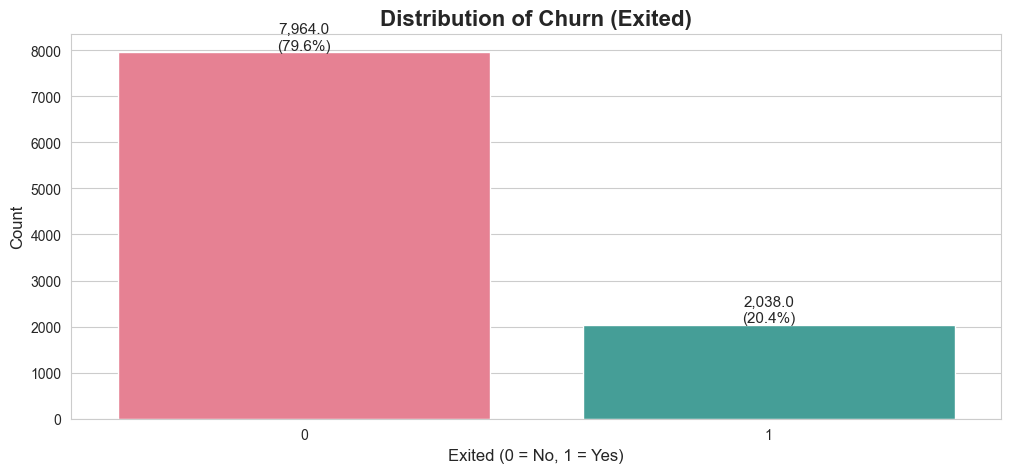

In [7]:
# Check the distribution of the target variable
print("Target Variable Distribution:")
print(processed_df['Exited'].value_counts())

# Calculate churn rate
churn_rate = processed_df['Exited'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

# Visualize the target variable distribution
fig, ax = plt.subplots(figsize=(12, 5))

# Create bar plot
sns.countplot(x='Exited', data=processed_df, palette='husl', ax=ax)
ax.set_title('Distribution of Churn (Exited)', fontsize=16, fontweight='bold')
ax.set_xlabel('Exited (0 = No, 1 = Yes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50, 
            f'{height:,}\n({height/len(processed_df)*100:.1f}%)', 
            ha="center", fontsize=11)

plt.show()

## Numerical Features Analysis

Let's explore the distribution of numerical features in the processed dataset, including the newly created ratio features and encoded variables.

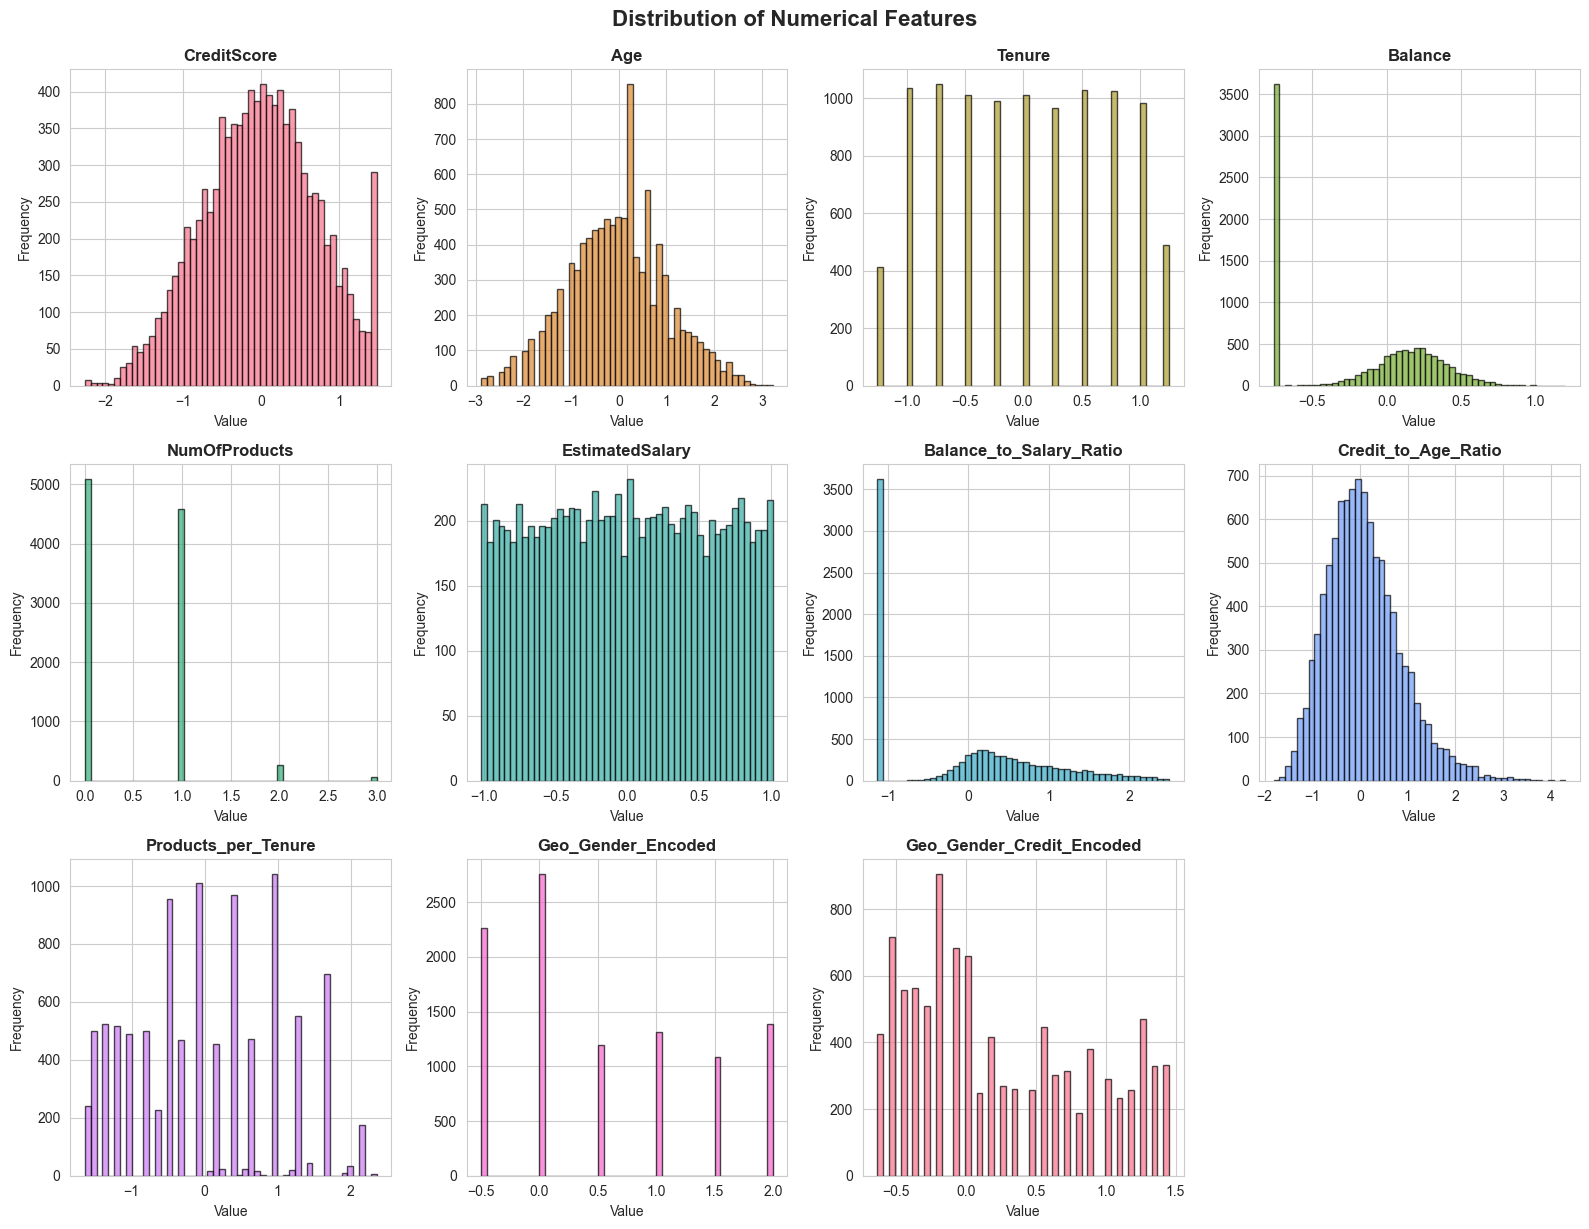

In [8]:
# Identify numerical columns
numerical_cols = processed_df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Exited')  # We'll analyze the target separately

# Select only the original and engineered numerical features for visualization
selected_numerical = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary',
                      'Balance_to_Salary_Ratio', 'Credit_to_Age_Ratio', 'Products_per_Tenure',
                      'Geo_Gender_Encoded', 'Geo_Gender_Credit_Encoded']

# Filter out columns that might not exist (in case of a mismatch)
existing_numerical = [col for col in selected_numerical if col in processed_df.columns]

# Create a subplot with histograms for numerical features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()  # Flatten the 3x4 grid into a 1D array

# Plot histograms for each numerical feature
for i, col in enumerate(existing_numerical):
    if i < len(axes):  # Only plot if we have space in our grid
        axes[i].hist(processed_df[col], bins=50, edgecolor='black', alpha=0.7, color=colors[i % len(colors)])
        axes[i].set_title(col, fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(existing_numerical), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution of Numerical Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Correlation Analysis of Numerical Features

Let's examine the correlations between the numerical features and the target variable 'Exited'.


===== CORRELATION TABLE =====

                           CreditScore     Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Balance_to_Salary_Ratio  Credit_to_Age_Ratio  Products_per_Tenure  Geo_Gender_Encoded  Geo_Gender_Credit_Encoded  Exited
CreditScore                     1.0000 -0.0067  0.0007   0.0064         0.0122    -0.0053          0.0254          -0.0016                   0.0069               0.4994               0.0067              0.0066                    -0.1034 -0.0269
Age                            -0.0067  1.0000 -0.0115   0.0309        -0.0296    -0.0116          0.0596          -0.0060                   0.0312              -0.8511              -0.0155              0.0158                     0.0150  0.2930
Tenure                          0.0007 -0.0115  1.0000  -0.0123         0.0134     0.0225         -0.0283           0.0078                  -0.0169               0.0106              -0.8204              0.0078                     0.0

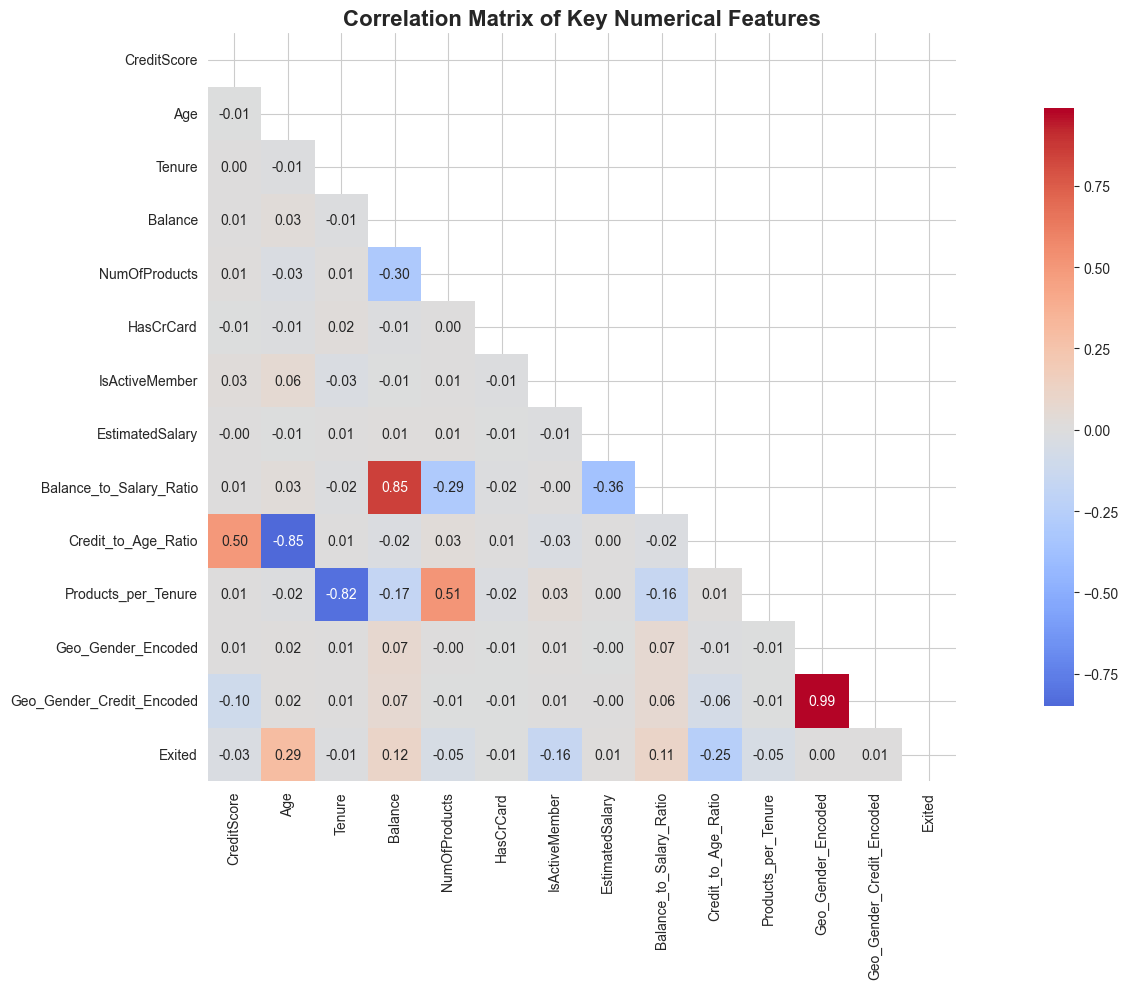

In [9]:
# Select only numerical columns that are meaningful to include in correlation matrix
# Exclude boolean-like columns that were converted to float for scaling purposes
numeric_for_corr = processed_df.select_dtypes(include=[np.number]).columns.tolist()

# Compute correlation matrix focusing on original and engineered numeric features
important_numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
                     'IsActiveMember', 'EstimatedSalary', 'Balance_to_Salary_Ratio', 
                     'Credit_to_Age_Ratio', 'Products_per_Tenure', 'Geo_Gender_Encoded', 
                     'Geo_Gender_Credit_Encoded', 'Exited']

# Ensure all columns exist in the dataframe
existing_corr_cols = [col for col in important_numeric if col in processed_df.columns]

# Create correlation matrix
corr_matrix = processed_df[existing_corr_cols].corr()

# Print correlation table in text
print("\n===== CORRELATION TABLE =====\n")
print(corr_matrix.to_string())


# Visualize the correlation matrix
plt.figure(figsize=(18, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Key Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Categorical Features Analysis

Now let's examine the binary categorical features that were engineered through one-hot encoding and other techniques.

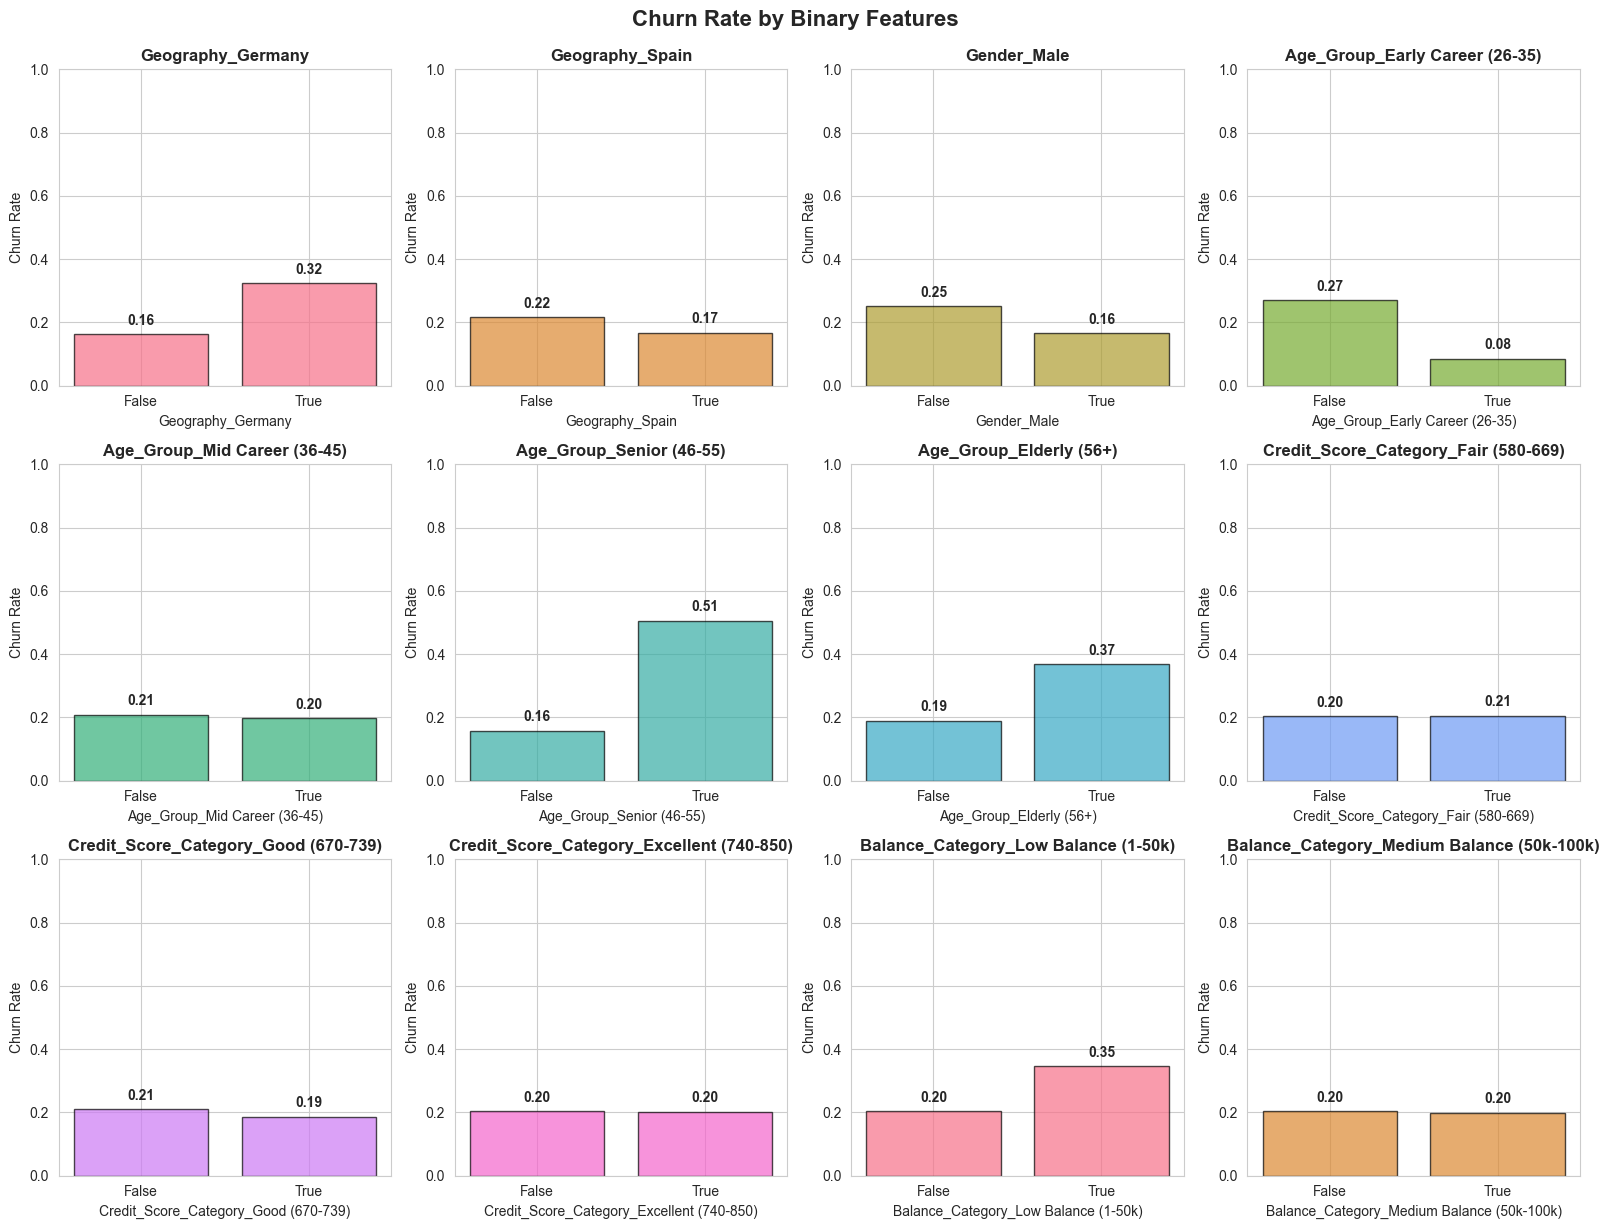

In [10]:
# Identify binary/categorical columns
binary_cols = processed_df.select_dtypes(include=['bool']).columns.tolist()

# Select important binary features for visualization
selected_binary = ['Geography_Germany', 'Geography_Spain', 'Gender_Male',
                   'Age_Group_Early Career (26-35)', 'Age_Group_Mid Career (36-45)',
                   'Age_Group_Senior (46-55)', 'Age_Group_Elderly (56+)',
                   'Credit_Score_Category_Fair (580-669)',
                   'Credit_Score_Category_Good (670-739)',
                   'Credit_Score_Category_Excellent (740-850)',
                   'Balance_Category_Low Balance (1-50k)',
                   'Balance_Category_Medium Balance (50k-100k)',
                   'Balance_Category_High Balance (100k+)']

# Filter out columns that might not exist
existing_binary = [col for col in selected_binary if col in processed_df.columns]

# Limit to first 12 binary features for readability
features_to_plot = existing_binary[:12]

# Create subplots for binary features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(features_to_plot):
    # Calculate mean of Exited for each category of the binary feature
    churn_by_feature = processed_df.groupby(col)['Exited'].mean()
    
    # Create bar plot
    axes[i].bar(churn_by_feature.index.astype(str), churn_by_feature.values, 
                color=colors[i % len(colors)], alpha=0.7, edgecolor='black')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_ylim(0, 1)
    
    # Add value labels on bars
    for idx, value in enumerate(churn_by_feature.values):
        axes[i].text(idx, value + 0.02, f'{value:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.suptitle('Churn Rate by Binary Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Missing Value Indicator Analysis

Let's analyze the missing value indicators that were added during feature engineering.

Missing Value Indicators:
HasCrCard_WasMissing: 10002
IsActiveMember_WasMissing: 10002
Geography_WasMissing: 10002
Gender_WasMissing: 0


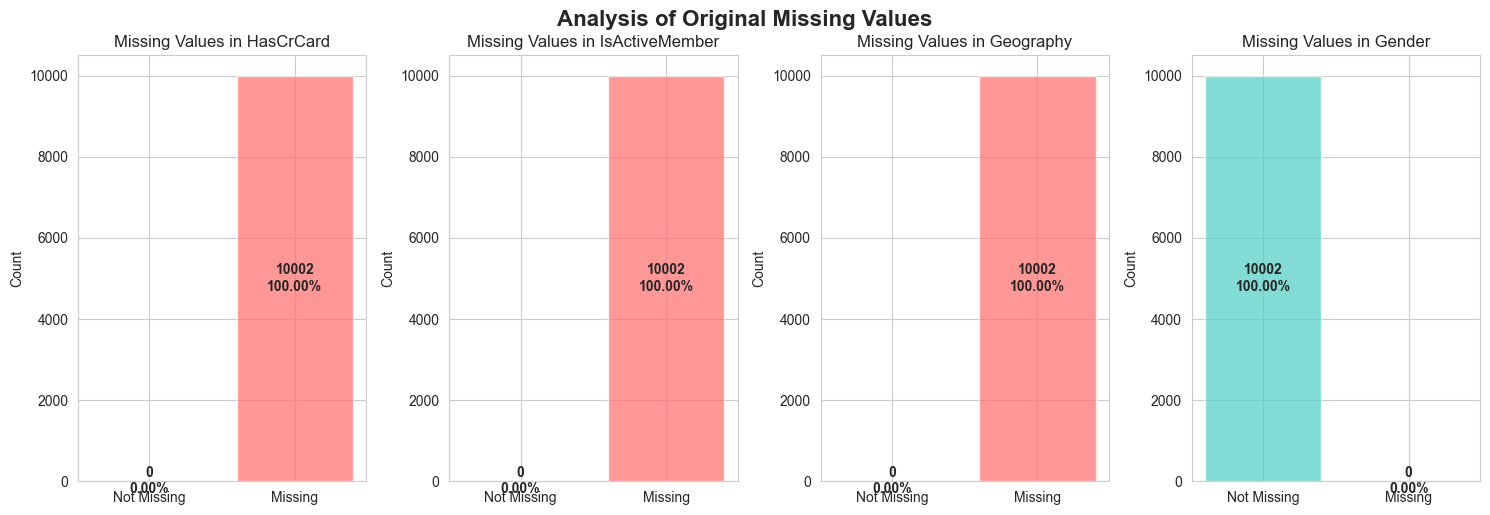

In [11]:
# Check for missing value indicator columns
missing_indicator_cols = [col for col in processed_df.columns if '_WasMissing' in col]

print("Missing Value Indicators:")
for col in missing_indicator_cols:
    print(f"{col}: {(processed_df[col] != 0).sum()}")

# Create visualization of missing value indicators
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, col in enumerate(missing_indicator_cols):
    # Count how many observations have missing values for each feature
    missing_count = (processed_df[col] != 0).sum()
    total_count = len(processed_df)
    missing_pct = (missing_count / total_count) * 100
    
    # Bar plot showing how many values were originally missing
    axes[i].bar([0, 1], [total_count - missing_count, missing_count], 
                color=['#4ECDC4', '#FF6B6B'], alpha=0.7)
    axes[i].set_title(f'Missing Values in {col.split("_")[0]}')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Not Missing', 'Missing'])
    
    # Add count and percentage labels on bars
    axes[i].text(0, (total_count - missing_count)/2, f'{total_count - missing_count}\n{100-missing_pct:.2f}%',
                 ha='center', va='center', fontweight='bold')
    axes[i].text(1, missing_count/2, f'{missing_count}\n{missing_pct:.2f}%',
                 ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.suptitle('Analysis of Original Missing Values', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Feature Engineering Effectiveness

Let's evaluate how effective our feature engineering was by comparing the relationships between features and churn.

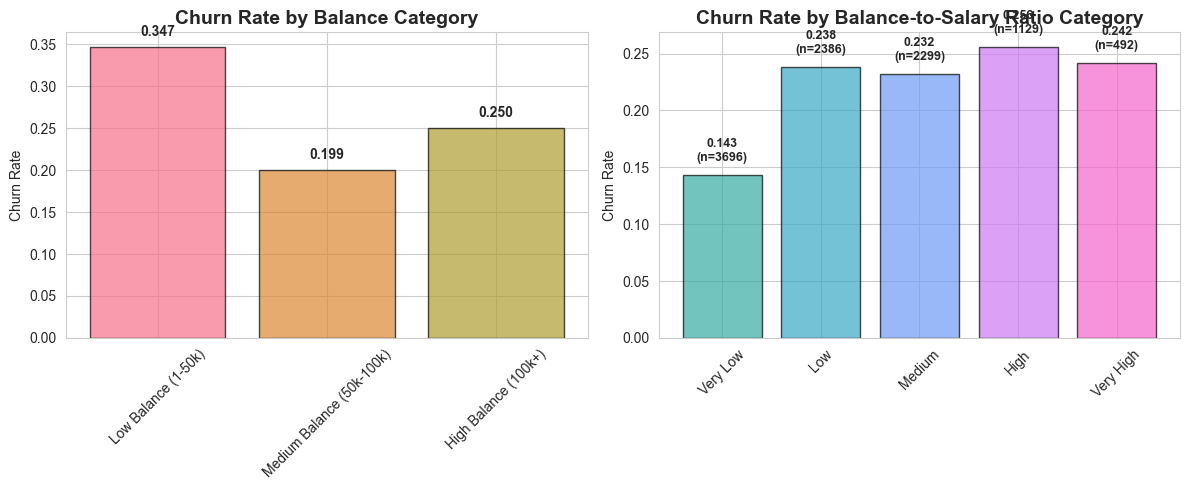

In [12]:
# Analyze the relationship between balance categories and churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Balance categories vs churn rate
balance_cat_cols = [col for col in processed_df.columns if 'Balance_Category' in col]
churn_by_balance_cat = []
labels = []

for col in balance_cat_cols:
    temp_df = processed_df[processed_df[col] == True]
    churn_rate = temp_df['Exited'].mean()
    churn_by_balance_cat.append(churn_rate)
    labels.append(col.replace('Balance_Category_', ''))

axes[0].bar(labels, churn_by_balance_cat, color=colors[:len(labels)], alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Rate by Balance Category', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(churn_by_balance_cat):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Balance-to-salary ratio vs churn rate
processed_df['Balance_Ratio_Binned'] = pd.cut(processed_df['Balance_to_Salary_Ratio'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
churn_by_ratio = processed_df.groupby('Balance_Ratio_Binned')['Exited'].agg(['mean', 'count']).reset_index()

axes[1].bar(churn_by_ratio['Balance_Ratio_Binned'], churn_by_ratio['mean'], 
             color=colors[5:10], alpha=0.7, edgecolor='black')
axes[1].set_title('Churn Rate by Balance-to-Salary Ratio Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=45)

# Add count labels for context
for i, row in churn_by_ratio.iterrows():
    axes[1].text(i, row['mean'] + 0.01, f'{row["mean"]:.3f}\n(n={row["count"]})', 
                  ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Clean up the temporary binned column
processed_df.drop('Balance_Ratio_Binned', axis=1, inplace=True)

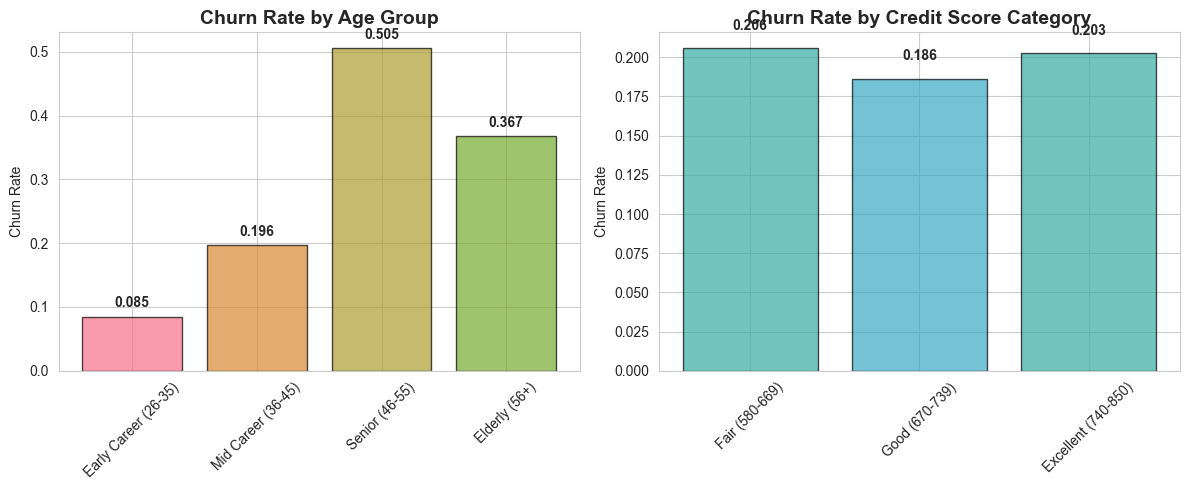

In [13]:
# Analyze age groups vs credit score categories and churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Age groups vs churn rate
age_group_cols = [col for col in processed_df.columns if 'Age_Group' in col and col in processed_df.columns]
churn_by_age_group = []
age_labels = []

for col in age_group_cols:
    temp_df = processed_df[processed_df[col] == True]
    churn_rate = temp_df['Exited'].mean()
    churn_by_age_group.append(churn_rate)
    age_labels.append(col.replace('Age_Group_', ''))

axes[0].bar(age_labels, churn_by_age_group, color=colors[:len(age_labels)], alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(churn_by_age_group):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Credit score categories vs churn rate
credit_cat_cols = [col for col in processed_df.columns if 'Credit_Score_Category' in col and col in processed_df.columns]
churn_by_credit_cat = []
credit_labels = []

for col in credit_cat_cols:
    temp_df = processed_df[processed_df[col] == True]
    churn_rate = temp_df['Exited'].mean()
    churn_by_credit_cat.append(churn_rate)
    credit_labels.append(col.replace('Credit_Score_Category_', ''))

axes[1].bar(credit_labels, churn_by_credit_cat, color=colors[5:7], alpha=0.7, edgecolor='black')
axes[1].set_title('Churn Rate by Credit Score Category', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(churn_by_credit_cat):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Geographic and Gender Analysis

Let's examine how geography and gender combinations affect churn rates using the engineered features.

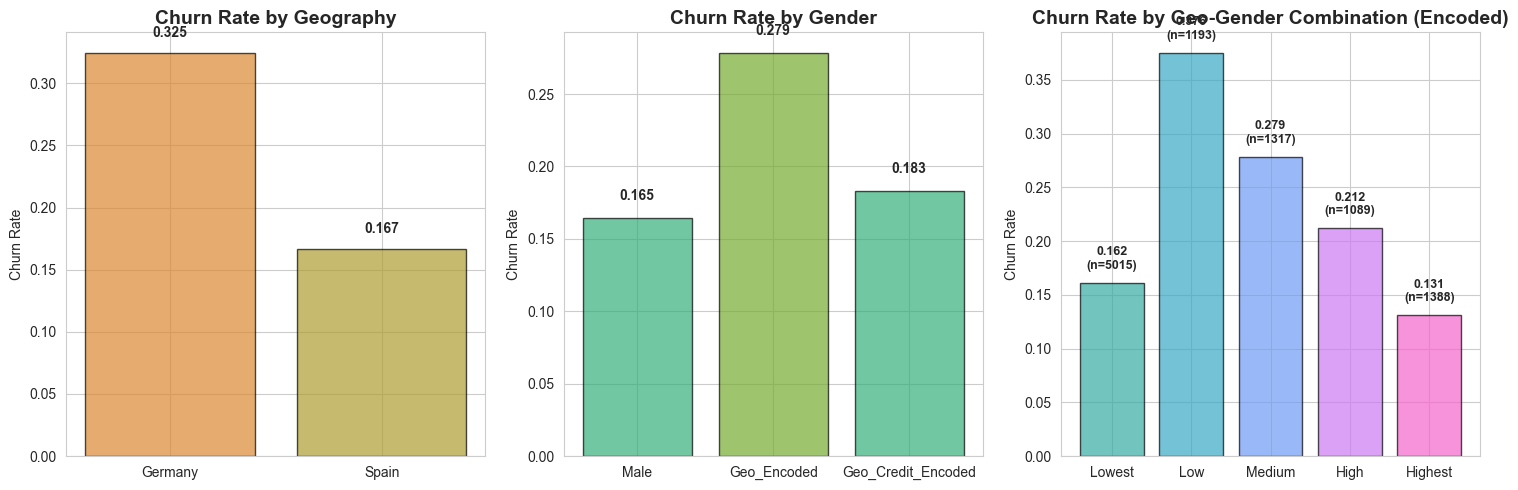

In [14]:
# Create visualizations for geographic and gender combinations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Geography vs Churn
geography_cols = [col for col in processed_df.columns if 'Geography_' in col and col in processed_df.columns]
geography_churn_rates = []
geog_labels = []

for col in geography_cols:
    temp_df = processed_df[processed_df[col] == True]
    churn_rate = temp_df['Exited'].mean()
    geography_churn_rates.append(churn_rate)
    geog_labels.append(col.replace('Geography_', ''))

bars1 = axes[0].bar(geog_labels, geography_churn_rates, color=colors[:3], alpha=0.7, edgecolor='black')
axes[0].set_title('Churn Rate by Geography', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate')

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars1, geography_churn_rates)):
    axes[0].text(bar.get_x() + bar.get_width()/2., rate + 0.01, f'{rate:.3f}',
                 ha='center', va='bottom', fontweight='bold')

# Plot 2: Gender vs Churn
gender_cols = [col for col in processed_df.columns if 'Gender_' in col and col in processed_df.columns]
gender_churn_rates = []
gender_labels = []

for col in gender_cols:
    temp_df = processed_df[processed_df[col] == True]
    churn_rate = temp_df['Exited'].mean()
    gender_churn_rates.append(churn_rate)
    gender_labels.append(col.replace('Gender_', ''))

bars2 = axes[1].bar(gender_labels, gender_churn_rates, color=colors[3:5], alpha=0.7, edgecolor='black')
axes[1].set_title('Churn Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate')

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars2, gender_churn_rates)):
    axes[1].text(bar.get_x() + bar.get_width()/2., rate + 0.01, f'{rate:.3f}',
                 ha='center', va='bottom', fontweight='bold')

# Plot 3: Geo-Gender combination vs Churn (using the encoded feature)
processed_df['Geo_Gender_Binned'] = pd.cut(processed_df['Geo_Gender_Encoded'], bins=5, labels=['Lowest', 'Low', 'Medium', 'High', 'Highest'])
churn_by_geo_gender = processed_df.groupby('Geo_Gender_Binned')['Exited'].agg(['mean', 'count']).reset_index()

bars3 = axes[2].bar(churn_by_geo_gender['Geo_Gender_Binned'], churn_by_geo_gender['mean'], 
                    color=colors[5:], alpha=0.7, edgecolor='black')
axes[2].set_title('Churn Rate by Geo-Gender Combination (Encoded)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Churn Rate')

# Add count labels for context
for i, row in churn_by_geo_gender.iterrows():
    axes[2].text(i, row['mean'] + 0.01, f'{row["mean"]:.3f}\n(n={row["count"]})', 
                  ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Clean up the temporary binned column
processed_df.drop('Geo_Gender_Binned', axis=1, inplace=True)

## Feature Importance Through Statistical Significance

Let's use statistical tests to determine which engineered features have the strongest relationship with customer churn.

Top Features by Absolute Correlation with Exited:
Age                                      0.2930
Age_Group_Senior (46-55)                 0.2909
Credit_to_Age_Ratio                      0.2534
Age_Group_Early Career (26-35)           0.2184
Geography_Germany                        0.1738
IsActiveMember                           0.1562
Active_Card_Holder_Inactive Card Holder  0.1253
Age_Group_Elderly (56+)                  0.1199
Balance                                  0.1185
Balance_Category_High Balance (100k+)    0.1098
Gender_Male                              0.1062
Balance_to_Salary_Ratio                  0.1053
Active_Card_Holder_Inactive Non-Card Holder 0.0533
Geography_Spain                          0.0527
NumOfProducts                            0.0476
Products_per_Tenure                      0.0469
Active_Card_Holder_Active Non-Card Holder 0.0423
Balance_Category_Low Balance (1-50k)     0.0308
CreditScore                              0.0269
Credit_Score_Category_Good (670-73

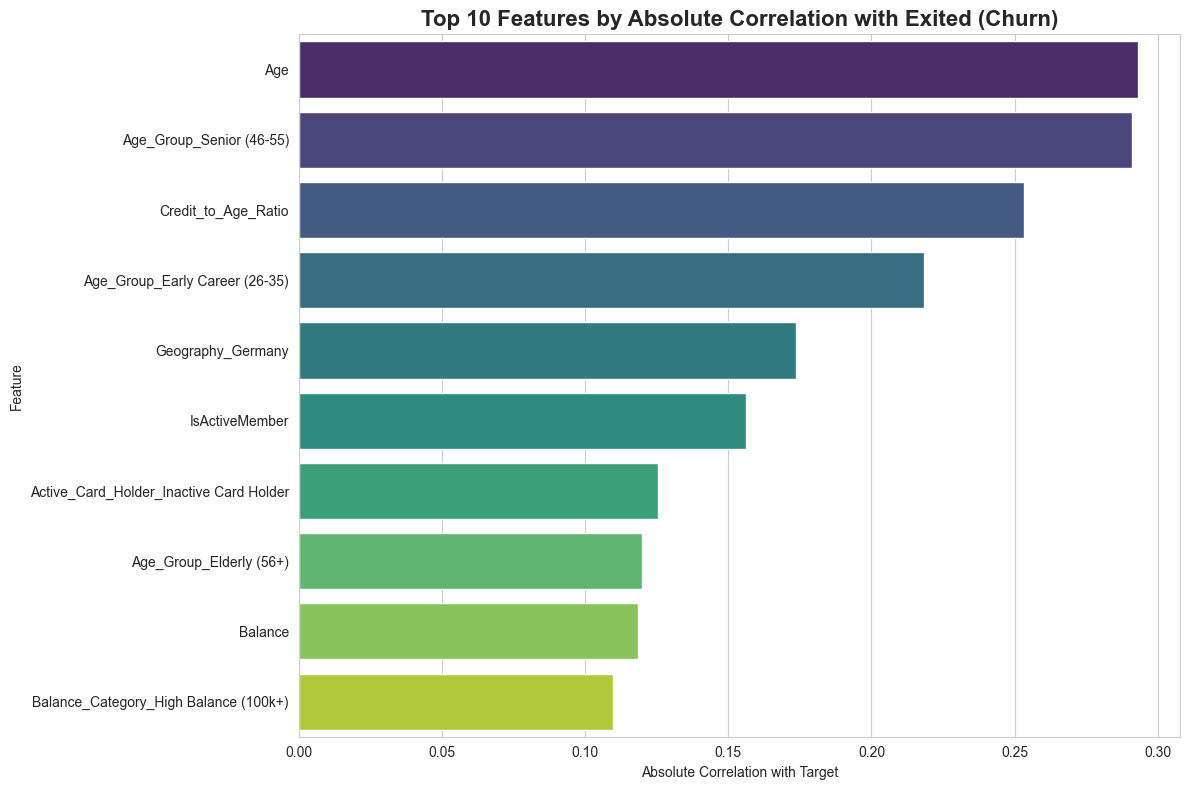

In [15]:
# Calculate correlation of each feature with the target variable
target_corr = processed_df.corr()['Exited'].drop('Exited').abs().sort_values(ascending=False)

print("Top Features by Absolute Correlation with Exited:")
for i, (feature, corr) in enumerate(target_corr.head(20).items()):
    print(f"{feature:<40} {corr:.4f}")

# Visualize top 10 features by correlation with the target
top_features = target_corr.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 10 Features by Absolute Correlation with Exited (Churn)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Absolute Correlation with Target')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Summary of Processed Dataset Analysis

Our EDA of the processed customer churn dataset reveals several important insights from the feature engineering process:

1. **Missing Value Patterns**: The missing indicator features show that some original features had missing values, which could be informative for our model.

2. **Engineered Ratio Features**: The Balance_to_Salary_Ratio and Credit_to_Age_Ratio provide meaningful insights into financial behavior and its relationship with churn.

3. **Binned Categorical Features**: Age and credit score categories seem to show distinct patterns in churn behavior, with elderly customers having higher churn rates.

4. **Combined Encodings**: The Geo_Gender_Encoded and Geo_Gender_Credit_Encoded features allow us to see complex interactions that might be predictive of churn.

5. **Correlation Insights**: The correlation analysis shows which engineered features have the strongest linear relationship with the churn target, helping prioritize features for modeling.

The processed dataset contains 36 features in total, including original numerical features, engineered ratios, dummy-encoded categorical variables, and combined encodings. This gives us a comprehensive feature set for modeling customer churn while maintaining interpretability through well-designed features.

## Handling Multicollinearity

The correlation matrix reveals strong correlations between several engineered features. This is expected since some features are derived from others (e.g., `Credit_to_Age_Ratio` from `CreditScore` and `Age`). This phenomenon, known as multicollinearity, can be problematic for some machine learning models as it introduces redundancy and can make model interpretation difficult.

To address this, we will identify pairs of features with very high correlation (e.g., > 0.8) and remove one feature from each pair. The feature to be removed will be the one with a lower correlation with the target variable, 'Exited'.

Features to drop due to high correlation (> 0.8):
['Balance_to_Salary_Ratio', 'Credit_to_Age_Ratio', 'Products_per_Tenure', 'Balance_Category_High Balance (100k+)', 'Geo_Gender_Encoded', 'Geo_Gender_Credit_Encoded']
Correlation with Exited:
Age                   0.2930
Credit_to_Age_Ratio   0.2534
Name: Exited, dtype: float64
Tenure                0.0141
Products_per_Tenure   0.0469
Name: Exited, dtype: float64
Balance                   0.1185
Balance_to_Salary_Ratio   0.1053
Name: Exited, dtype: float64
Geo_Gender_Encoded          0.0039
Geo_Gender_Credit_Encoded   0.0052
Name: Exited, dtype: float64
Dropped columns: ['Credit_to_Age_Ratio', 'Tenure', 'Balance_to_Salary_Ratio', 'Geo_Gender_Encoded']
Shape of the final dataset: (10002, 33)


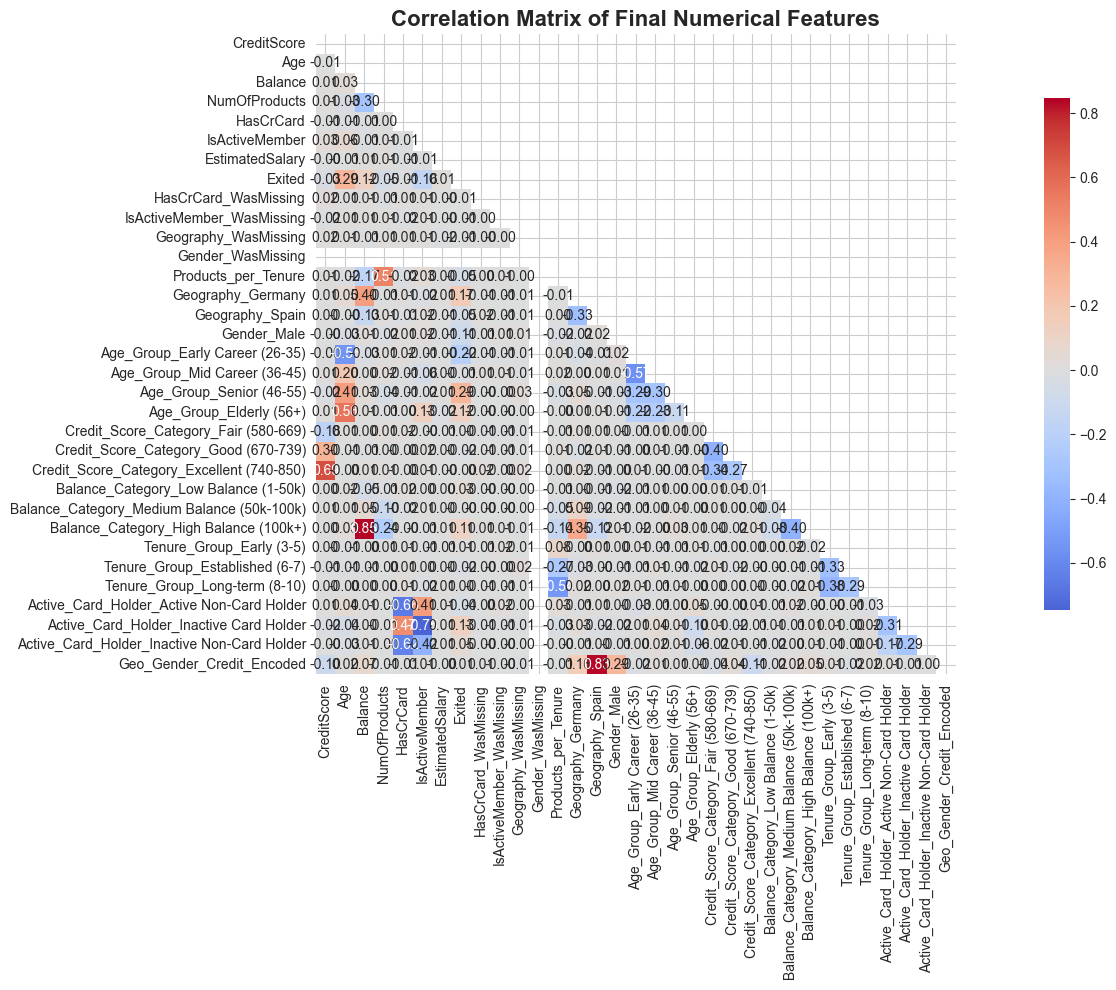

In [16]:
# Create a copy of the processed dataframe to work with
df_final = processed_df.copy()

# Correlation matrix
corr_matrix = df_final.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find index of feature columns with correlation greater than 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("Features to drop due to high correlation (> 0.8):")
print(to_drop)

# High correlation pairs (abs > 0.8):
# - Age and Credit_to_Age_Ratio (0.85)
# - Tenure and Products_per_Tenure (0.82)
# - Balance and Balance_to_Salary_Ratio (0.85)
# - Geo_Gender_Encoded and Geo_Gender_Credit_Encoded (0.99)

# Let's check their correlation with 'Exited'
corr_with_target = processed_df.corr()['Exited'].abs()
print("Correlation with Exited:")
print(corr_with_target[['Age', 'Credit_to_Age_Ratio']])
print(corr_with_target[['Tenure', 'Products_per_Tenure']])
print(corr_with_target[['Balance', 'Balance_to_Salary_Ratio']])
print(corr_with_target[['Geo_Gender_Encoded', 'Geo_Gender_Credit_Encoded']])


# Based on this:
# - Drop 'Credit_to_Age_Ratio' (corr 0.25) vs 'Age' (corr 0.29)
# - Drop 'Tenure' (corr 0.014) vs 'Products_per_Tenure' (corr 0.047)
# - Drop 'Balance_to_Salary_Ratio' (corr 0.105) vs 'Balance' (corr 0.118)
# - Drop 'Geo_Gender_Encoded' (corr 0.0039) vs 'Geo_Gender_Credit_Encoded' (corr 0.0052)

features_to_drop = ['Credit_to_Age_Ratio', 'Tenure', 'Balance_to_Salary_Ratio', 'Geo_Gender_Encoded']

df_final = df_final.drop(columns=features_to_drop)

print(f"Dropped columns: {features_to_drop}")
print(f"Shape of the final dataset: {df_final.shape}")

# Display the correlation matrix of the final dataset
corr_matrix_final = df_final.corr()
plt.figure(figsize=(18, 10))
mask = np.triu(np.ones_like(corr_matrix_final, dtype=bool))
sns.heatmap(corr_matrix_final, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Final Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Processed Dataset

After removing the highly correlated features, we have our final processed dataset. This dataset is now ready for model training. We will save it to a new file.

In [17]:
# Save the final processed dataset
df_final.to_csv('../data/processed/customer_churn_data_final.csv', index=False)

print("Final processed dataset saved to 'Churn_Modelling_Final.csv'")
print(df_final.info())
df_final.head()

Final processed dataset saved to 'Churn_Modelling_Final.csv'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 33 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   CreditScore                                  10002 non-null  float64
 1   Age                                          10002 non-null  float64
 2   Balance                                      10002 non-null  float64
 3   NumOfProducts                                10002 non-null  float64
 4   HasCrCard                                    10002 non-null  float64
 5   IsActiveMember                               10002 non-null  float64
 6   EstimatedSalary                              10002 non-null  float64
 7   Exited                                       10002 non-null  int64  
 8   HasCrCard_WasMissing                         10002 non-null  float64
 9   IsActiveMem

,CreditScore,Age,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasCrCard_WasMissing,IsActiveMember_WasMissing,Geography_WasMissing,Gender_WasMissing,Products_per_Tenure,Geography_Germany,Geography_Spain,Gender_Male,Age_Group_Early Career (26-35),Age_Group_Mid Career (36-45),Age_Group_Senior (46-55),Age_Group_Elderly (56+),Credit_Score_Category_Fair (580-669),Credit_Score_Category_Good (670-739),Credit_Score_Category_Excellent (740-850),Balance_Category_Low Balance (1-50k),Balance_Category_Medium Balance (50k-100k),Balance_Category_High Balance (100k+),Tenure_Group_Early (3-5),Tenure_Group_Established (6-7),Tenure_Group_Long-term (8-10),Active_Card_Holder_Active Non-Card Holder,Active_Card_Holder_Inactive Card Holder,Active_Card_Holder_Inactive Non-Card Holder,Geo_Gender_Credit_Encoded
0,-0.2463,0.4662,-0.7615,0.0000,0.0000,0.0000,0.0118,1,-0.0100,-0.0100,-0.0100,0.0000,0.3783,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,-0.5455
1,-0.3284,0.3765,-0.1049,0.0000,-1.0000,0.0000,0.1256,0,-0.0100,-0.0100,-0.0100,0.0000,0.9427,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,0.9091
2,-1.1194,0.4662,0.4893,2.0000,0.0000,-1.0000,0.1397,1,-0.0100,-0.0100,-0.0100,0.0000,0.3783,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,-0.3636
3,0.3507,0.1868,-0.7615,1.0000,-1.0000,-1.0000,-0.0646,0,-0.0100,-0.0100,-0.0100,0.0000,1.6768,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,-0.4545
4,1.4776,0.5528,0.2218,0.0000,0.0000,0.0000,-0.2144,0,100.0050,-0.0100,-0.0100,0.0000,0.3783,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,0.8182
